In [1]:
import requests
import pandas as pd
import sqlite3
from datetime import datetime

def fetch_weather():
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": 29.87,
        "longitude": 77.89,
        "current_weather": True
    }
    response = requests.get(url, params=params)
    data = response.json()
    current = data['current_weather']

    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "temperature": current['temperature'],
        "windspeed": current['windspeed'],
        "weathercode": current['weathercode'],
        "city": "Roorkee"
    }
    return pd.DataFrame([row])

def save_to_db(df, table_name):
    conn = sqlite3.connect("data/city_pulse.db")
    df.to_sql(table_name, conn, if_exists="append", index=False)
    conn.close()

df_weather = fetch_weather()
save_to_db(df_weather, "weather_logs")
print("✅ Weather saved!")
df_weather

✅ Weather saved!


,timestamp,temperature,windspeed,weathercode,city
0,2026-06-19 14:18:54,35.7,10.5,95,Roorkee


In [2]:
def fetch_air_quality():
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": 29.87,
        "longitude": 77.89,
        "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide"
    }
    response = requests.get(url, params=params)
    data = response.json()

    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "pm2_5": data['hourly']['pm2_5'][0],
        "pm10": data['hourly']['pm10'][0],
        "carbon_monoxide": data['hourly']['carbon_monoxide'][0],
        "nitrogen_dioxide": data['hourly']['nitrogen_dioxide'][0],
        "city": "Roorkee"
    }
    return pd.DataFrame([row])

df_air = fetch_air_quality()
save_to_db(df_air, "air_quality_logs")
print("✅ Air quality saved!")
df_air

✅ Air quality saved!


,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,city
0,2026-06-19 14:19:35,70.1,97.6,745.0,42.4,Roorkee


In [3]:
from textblob import TextBlob

# Real world: Swiggy reads reviews → auto tags positive/negative
# We: Read citizen complaints → find positive/negative

complaints = [
    "Water supply has been cut for 3 days in sector 5",
    "Roads are excellent after repair, very smooth now",
    "Garbage not collected since Monday, very bad smell",
    "Street lights working perfectly, feel safe at night",
    "Electricity goes off every evening for 2 hours",
    "New park is beautiful, children love playing there",
    "Drainage system is blocked, water flooding the road",
    "Bus service is very punctual and clean"
]

rows = []
for text in complaints:
    blob = TextBlob(text)
    score = blob.sentiment.polarity

    if score > 0.1:
        label = "Positive"
    elif score < -0.1:
        label = "Negative"
    else:
        label = "Neutral"

    rows.append({
        "complaint": text,
        "sentiment_score": round(score, 2),
        "sentiment_label": label
    })

df_complaints = pd.DataFrame(rows)
save_to_db(df_complaints, "complaints_analysis")
print("✅ Complaints analyzed!")
df_complaints


ModuleNotFoundError: No module named 'textblob'

In [4]:
!pip install textblob
!python -m textblob.download_corpora

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 1.2 MB/s  0:00:00
Finished.


[nltk_data] Downloading package brown to C:\Users\DISHA
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\brown.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\DISHA
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to C:\Users\DISHA
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DISHA SHARMA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to C:\Users\DISHA
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\conll2000.zip.
[nltk_data] Downloading package movie_reviews to C:\Users\DISHA
[nltk_data]     SHARMA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.


In [5]:
from textblob import TextBlob

# Real world: Swiggy reads reviews → auto tags positive/negative
# We: Read citizen complaints → find positive/negative

complaints = [
    "Water supply has been cut for 3 days in sector 5",
    "Roads are excellent after repair, very smooth now",
    "Garbage not collected since Monday, very bad smell",
    "Street lights working perfectly, feel safe at night",
    "Electricity goes off every evening for 2 hours",
    "New park is beautiful, children love playing there",
    "Drainage system is blocked, water flooding the road",
    "Bus service is very punctual and clean"
]

rows = []
for text in complaints:
    blob = TextBlob(text)
    score = blob.sentiment.polarity

    if score > 0.1:
        label = "Positive"
    elif score < -0.1:
        label = "Negative"
    else:
        label = "Neutral"

    rows.append({
        "complaint": text,
        "sentiment_score": round(score, 2),
        "sentiment_label": label
    })

df_complaints = pd.DataFrame(rows)
save_to_db(df_complaints, "complaints_analysis")
print("✅ Complaints analyzed!")
df_complaints

✅ Complaints analyzed!


,complaint,sentiment_score,sentiment_label
0,Water supply has been cut for 3 days in sector 5,0.00,Neutral
1,"Roads are excellent after repair, very smooth now",0.76,Positive
2,"Garbage not collected since Monday, very bad s...",-0.91,Negative
3,"Street lights working perfectly, feel safe at ...",0.75,Positive
4,Electricity goes off every evening for 2 hours,0.00,Neutral
5,"New park is beautiful, children love playing t...",0.50,Positive
6,"Drainage system is blocked, water flooding the...",0.00,Neutral
7,Bus service is very punctual and clean,0.28,Positive


In [6]:
!pip install textblob scikit-learn statsmodels plotly pandas requests openpyxl streamlit


In [7]:
from sklearn.ensemble import IsolationForest
import random

random.seed(42)

# Simulate 30 days normal weather
rows = []
for i in range(30):
    rows.append({
        "timestamp": f"2024-06-{i+1:02d}",
        "temperature": round(random.uniform(28, 38), 1),
        "windspeed": round(random.uniform(5, 20), 1)
    })

# Add 2 anomalies
rows.append({"timestamp": "2024-07-01", "temperature": 65.0, "windspeed": 5.0})
rows.append({"timestamp": "2024-07-02", "temperature": 10.0, "windspeed": 95.0})

df_anomaly = pd.DataFrame(rows)

model = IsolationForest(contamination=0.1, random_state=42)
df_anomaly['anomaly_flag'] = model.fit_predict(df_anomaly[['temperature','windspeed']])
df_anomaly['status'] = df_anomaly['anomaly_flag'].apply(
    lambda x: 'Unusual' if x == -1 else 'Normal'
)

save_to_db(df_anomaly, "weather_anomalies")
print("✅ Anomaly detection done!")
df_anomaly[['timestamp','temperature','windspeed','status']]

✅ Anomaly detection done!


,timestamp,temperature,windspeed,status
0,2024-06-01,34.4,5.4,Normal
1,2024-06-02,30.8,8.3,Normal
2,2024-06-03,35.4,15.2,Normal
3,2024-06-04,36.9,6.3,Normal
4,2024-06-05,32.2,5.4,Normal
5,2024-06-06,30.2,12.6,Normal
6,2024-06-07,28.3,8.0,Normal
7,2024-06-08,34.5,13.2,Normal
8,2024-06-09,30.2,13.8,Normal
9,2024-06-10,36.1,5.1,Normal


In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Real world: Weather app predicts next 7 days
# We: Predict next 7 days temperature for Roorkee

temp_series = df_anomaly['temperature'].iloc[:30].reset_index(drop=True)
model = ExponentialSmoothing(temp_series, trend='add').fit()
forecast = model.forecast(7)

df_forecast = pd.DataFrame({
    "day": [f"Day +{i}" for i in range(1, 8)],
    "forecasted_temp": forecast.round(1).values
})

save_to_db(df_forecast, "forecast")
print("✅ Forecast done!")
df_forecast

✅ Forecast done!


,day,forecasted_temp
0,Day +1,31.8
1,Day +2,31.7
2,Day +3,31.6
3,Day +4,31.6
4,Day +5,31.5
5,Day +6,31.4
6,Day +7,31.4


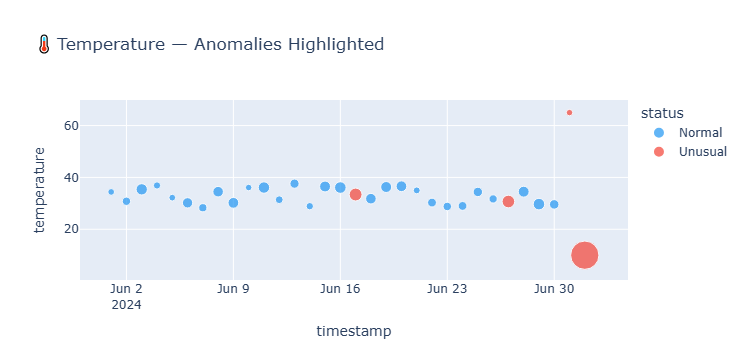

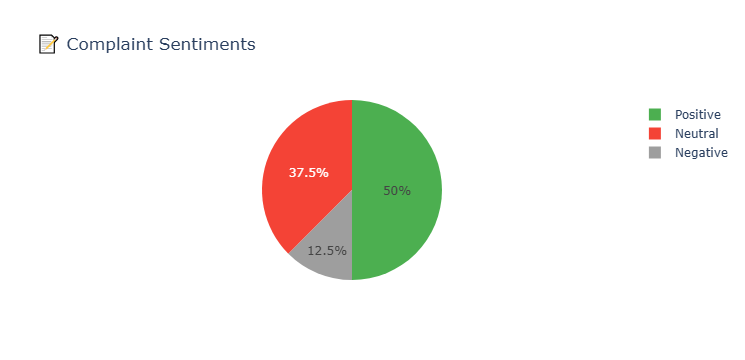

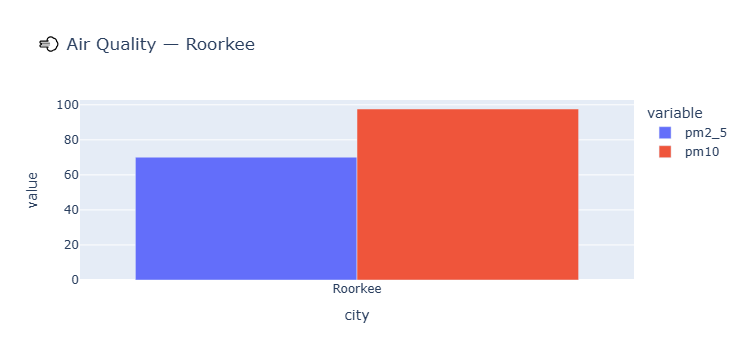

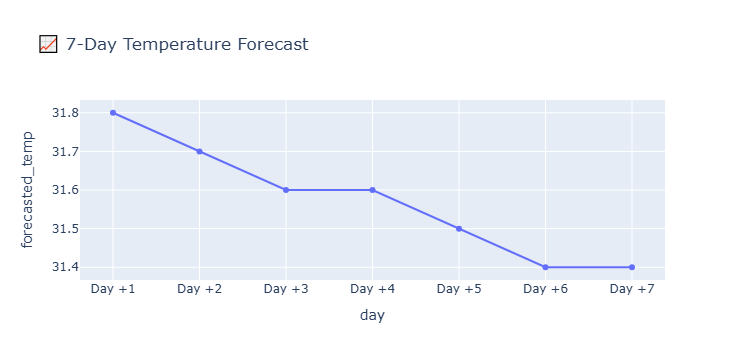

✅ All charts saved in output/charts/


In [9]:
import plotly.express as px

# Chart 1 - Anomalies
fig1 = px.scatter(
    df_anomaly, x='timestamp', y='temperature',
    color='status', size='windspeed',
    title='🌡️ Temperature — Anomalies Highlighted',
    color_discrete_map={'Normal':'#2196F3','Unusual':'#F44336'}
)
fig1.write_html("output/charts/anomalies.html")
fig1.show()

# Chart 2 - Sentiment
fig2 = px.pie(
    df_complaints, names='sentiment_label',
    title='📝 Complaint Sentiments',
    color_discrete_sequence=['#4CAF50','#F44336','#9E9E9E']
)
fig2.write_html("output/charts/sentiment.html")
fig2.show()

# Chart 3 - Air Quality
fig3 = px.bar(
    df_air, x='city', y=['pm2_5','pm10'],
    title='💨 Air Quality — Roorkee',
    barmode='group'
)
fig3.write_html("output/charts/air_quality.html")
fig3.show()

# Chart 4 - Forecast
fig4 = px.line(
    df_forecast, x='day', y='forecasted_temp',
    title='📈 7-Day Temperature Forecast',
    markers=True
)
fig4.write_html("output/charts/forecast.html")
fig4.show()

print("✅ All charts saved in output/charts/")

In [1]:
import os

os.chdir("C:/Users/DISHA SHARMA/projects/city-smart-pulse")
print("✅ Working directory:", os.getcwd())

✅ Working directory: C:\Users\DISHA SHARMA\projects\city-smart-pulse
